# Track 5: Group Relative Policy Optimization (GRPO) for Mathematical Reasoning

This notebook demonstrates fine-tuning **Qwen2.5-0.5B-Instruct** on mathematical reasoning problems from the `openai/gsm8k` dataset using **Group Relative Policy Optimization (GRPO)** over 250 steps. We configure reinforcement learning rewards based on format correctness (1.0 weight) and solution accuracy (3.0 weight) to teach the model strict XML reasoning and answer tags (`<reasoning>` and `<answer>`).

## 1. Setup Environment and Imports
We load libraries and establish system prompt instructions enforcing a strict XML reasoning and answer format.

In [1]:
import re

import os

import sys

import torch

import warnings

from datasets import load_dataset

from transformers import AutoTokenizer, AutoModelForCausalLM

from peft import LoraConfig

from trl import GRPOTrainer, GRPOConfig


warnings.filterwarnings("ignore")

os.environ["TOKENIZERS_PARALLELISM"] = "false"


compute_dtype = (
    torch.bfloat16
    if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
    else torch.float16
)

print(f"CUDA available: {torch.cuda.is_available()} | Compute Dtype: {compute_dtype}")

CUDA available: True | Compute Dtype: torch.bfloat16


## 2. Dataset Preparation (GSM8K)
We load the GSM8K dataset. We format each question with a system instruction that instructs the model to put its reasoning inside `<reasoning>` tags and the final numeric answer inside `<answer>` tags.

In [2]:
SYSTEM_PROMPT = (
    "A conversation between User and Assistant. The user asks a question, and the Assistant solves it.\n"
    "The assistant first thinks about the reasoning process in the mind and then provides the user with the answer.\n"
    "The reasoning process and answer are enclosed within tags. The answer must be a single integer.\n"
    "Example:\n"
    "<reasoning>\n"
    "We know that 2 + 2 = 4.\n"
    "</reasoning>\n"
    "<answer>4</answer>"
)


def extract_hash_answer(text: str) -> str | None:

    if "####" not in text:
        return None

    return text.split("####")[1].strip()


dataset = load_dataset("openai/gsm8k", "main", split="train")
dataset = dataset.shuffle(seed=42)

def format_gsm8k(example):

    return {
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": example["question"]},
        ],
        "answer": extract_hash_answer(example["answer"]),
    }


gsm8k_train = dataset.map(format_gsm8k)


print("Sample Prompt Structure Preview:\n", gsm8k_train[0]["prompt"])

Sample Prompt Structure Preview:
 [{'role': 'system', 'content': 'A conversation between User and Assistant. The user asks a question, and the Assistant solves it.\nThe assistant first thinks about the reasoning process in the mind and then provides the user with the answer.\nThe reasoning process and answer are enclosed within tags. The answer must be a single integer.\nExample:\n<reasoning>\nWe know that 2 + 2 = 4.\n</reasoning>\n<answer>4</answer>'}, {'role': 'user', 'content': 'Mimi picked up 2 dozen seashells on the beach.  Kyle found twice as many shells as Mimi and put them in his pocket. Leigh grabbed one-third of the shells that Kyle found.  How many seashells did Leigh have?'}]


## 3. Define RL Rewards
We define two reward functions:
1. **Format Reward**: Returns `1.0` if the output strictly matches the `<reasoning>...</reasoning>\n<answer>...</answer>` tags.
2. **Correctness Reward**: Returns `2.0` if the extracted answer matches the ground truth, and `0.0` otherwise.

In [3]:
def extract_last_number(text, start_tag="<answer>", end_tag="</answer>"):
    pattern = re.escape(start_tag) + r"(.*?)" + re.escape(end_tag)
    matches = re.findall(pattern, text, re.DOTALL)
    text_to_search = matches[-1] if matches else text
    numbers = re.findall(r"-?\d+(?:,\d{3})*(?:\.\d+)?", text_to_search)
    if numbers:
        return numbers[-1].replace(",", "").strip()
    return ""


def format_reward(completions, **kwargs):
    pattern = r"^<reasoning>[\s\S]*?<\/reasoning>\s*<answer>[\s\S]*?<\/answer>$"
    responses = [completion[0]["content"] for completion in completions]
    rewards = [0.5 if re.match(pattern, response) else 0.0 for response in responses]
    return rewards


def correctness_reward(completions, answer, **kwargs):
    responses = [completion[0]["content"] for completion in completions]
    extracted = [extract_last_number(response) for response in responses]
    rewards = [2.0 if ext == ans else 0.0 for ext, ans in zip(extracted, answer)]
    return rewards

## 3.5. Evaluate Pre-Trained Model Before GRPO Alignment
To demonstrate GRPO's capability to teach both format compliance and mathematical accuracy, we evaluate the un-finetuned `Qwen2.5-0.5B-Instruct` model on 5 test questions from GSM8K before starting RL training.

In [4]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")

base_model_eval = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-0.5B-Instruct", dtype=compute_dtype, device_map="auto"
)
base_model_eval.eval()
base_model_eval.generation_config.max_length = None

eval_dataset_100 = load_dataset("openai/gsm8k", "main", split="test").select(range(100))
pre_grpo_responses_100 = []
pre_grpo_correct = 0
pre_grpo_format = 0

pattern = r"^<reasoning>[\s\S]*?<\/reasoning>\s*<answer>[\s\S]*?<\/answer>$"


print("=== Running Pre-GRPO Benchmark on 100 GSM8K Test Problems ===")

for i, example in enumerate(eval_dataset_100):
    question = example["question"]
    ground_truth = extract_hash_answer(example["answer"])
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    )
    input_ids = inputs if isinstance(inputs, torch.Tensor) else inputs["input_ids"]
    input_ids = input_ids.to("cuda")

    with torch.no_grad():
        outputs = base_model_eval.generate(
            input_ids=input_ids, max_new_tokens=384, pad_token_id=tokenizer.eos_token_id
        )

    resp = tokenizer.decode(
        outputs[0][input_ids.shape[1] :], skip_special_tokens=True
    ).strip()

    pre_grpo_responses_100.append(resp)
    ext_ans = extract_last_number(resp)

    if ext_ans == ground_truth:
        pre_grpo_correct += 1

    if re.match(pattern, resp):
        pre_grpo_format += 1

    if (i + 1) % 20 == 0:
        print(
            f"Evaluated {i + 1}/100 problems | Current Accuracy: {pre_grpo_correct / (i + 1) * 100:.1f}%"
        )


pre_acc = (pre_grpo_correct / 100) * 100
pre_fmt = (pre_grpo_format / 100) * 100

print(f"\n>>> PRE-GRPO BENCHMARK (100 Problems) <<<")
print(f"Format Compliance: {pre_fmt:.1f}% ({pre_grpo_format}/100)")
print(f"Math Accuracy:     {pre_acc:.1f}% ({pre_grpo_correct}/100)\n")


# Free GPU VRAM

del base_model_eval

torch.cuda.empty_cache()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

=== Running Pre-GRPO Benchmark on 100 GSM8K Test Problems ===


Evaluated 20/100 problems | Current Accuracy: 30.0%


Evaluated 40/100 problems | Current Accuracy: 32.5%


Evaluated 60/100 problems | Current Accuracy: 30.0%


Evaluated 80/100 problems | Current Accuracy: 27.5%


Evaluated 100/100 problems | Current Accuracy: 29.0%

>>> PRE-GRPO BENCHMARK (100 Problems) <<<
Format Compliance: 0.0% (0/100)
Math Accuracy:     29.0% (29/100)



## 4. Run GRPOTrainer using vLLM
We load the tokenizer and define the LoRA parameters. We use `vLLM` inside the trainer with a configured device and VRAM footprint to scale policy rollouts rapidly.

In [5]:
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


peft_config = LoraConfig(
    lora_alpha=32,
    lora_dropout=0.0,
    r=64,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)


training_args = GRPOConfig(
    use_vllm=True,
    learning_rate=1e-5,
    adam_beta1=0.9,
    adam_beta2=0.99,
    weight_decay=0.1,
    warmup_steps=25,
    beta=0.05,
    lr_scheduler_type="cosine",
    optim="adamw_8bit",
    bf16=(compute_dtype == torch.bfloat16),
    fp16=(compute_dtype == torch.float16),
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    gradient_accumulation_steps=4,
    per_device_train_batch_size=2,
    num_generations=8,
    temperature=0.7,
    max_completion_length=384,
    max_steps=250,
    logging_steps=10,
    save_steps=50,
    max_grad_norm=0.1,
    report_to="none",
    output_dir="qwen2.5-0.5b-grpo-output",
)


model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype=compute_dtype, device_map="auto"
)

if not hasattr(model, "warnings_issued"):
    model.warnings_issued = {}


trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[
        correctness_reward, 
        format_reward
        ],
    args=training_args,
    train_dataset=gsm8k_train,
    peft_config=peft_config,
)

trainer.train()

merged_model = trainer.model.merge_and_unload()
tokenizer.save_pretrained("qwen2.5-0.5b-grpo-adapter")
merged_model.save_pretrained("qwen2.5-0.5b-grpo-adapter")
print("GRPO training completed and model saved!")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


2026-07-22 17:57:26,783 - INFO - autotuner.py:651 - flashinfer.jit: [Autotuner]: Autotuning process starts ...


2026-07-22 17:57:26,837 - INFO - autotuner.py:674 - flashinfer.jit: [Autotuner]: Autotuning process ends


Capturing CUDA graphs (PIECEWISE):   0%|                            | 0/5 [00:00<?, ?it/s]

...

Capturing CUDA graphs (FULL): 100%|█████████████████████████| 4/4 [00:00<00:00, 33.08it/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,-0.133277
20,0.010466
30,0.006068
40,0.068534
50,-0.081325
60,-0.025281
70,-0.020886
80,-0.075409
90,-0.033214
100,-0.088458


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

GRPO training completed and model saved!


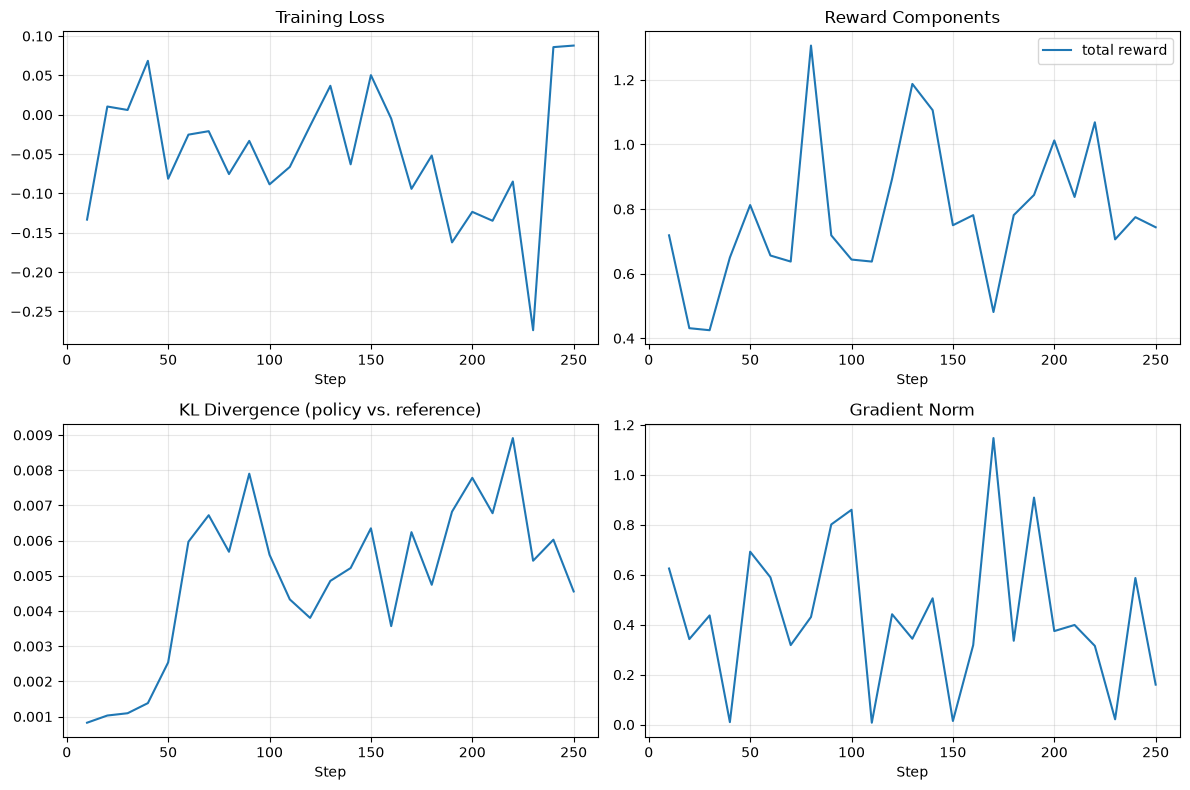

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

logs = pd.DataFrame(trainer.state.log_history)
logs = logs[logs["step"].notna()]  # drop any non-step entries

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

if "loss" in logs:
    axes[0, 0].plot(logs["step"], logs["loss"])
    axes[0, 0].set_title("Training Loss")

if "reward" in logs:
    axes[0, 1].plot(logs["step"], logs["reward"], label="total reward")
    if "rewards/correctness_reward" in logs:
        axes[0, 1].plot(logs["step"], logs["rewards/correctness_reward"], label="correctness", alpha=0.7)
    if "rewards/format_reward" in logs:
        axes[0, 1].plot(logs["step"], logs["rewards/format_reward"], label="format", alpha=0.7)
    axes[0, 1].set_title("Reward Components")
    axes[0, 1].legend()

if "kl" in logs:
    axes[1, 0].plot(logs["step"], logs["kl"])
    axes[1, 0].set_title("KL Divergence (policy vs. reference)")

if "grad_norm" in logs:
    axes[1, 1].plot(logs["step"], logs["grad_norm"])
    axes[1, 1].set_title("Gradient Norm")

for ax in axes.flat:
    ax.set_xlabel("Step")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Step 50: accuracy=36.0%, format=0.0%


Step 100: accuracy=36.0%, format=0.0%


Step 150: accuracy=31.0%, format=0.0%


Step 200: accuracy=39.0%, format=0.0%


...

Step 300: accuracy=43.0%, format=62.0%


Step 350: accuracy=42.0%, format=47.0%


Step 400: accuracy=38.0%, format=26.0%


Step 450: accuracy=44.0%, format=27.0%


Step 500: accuracy=45.0%, format=27.0%


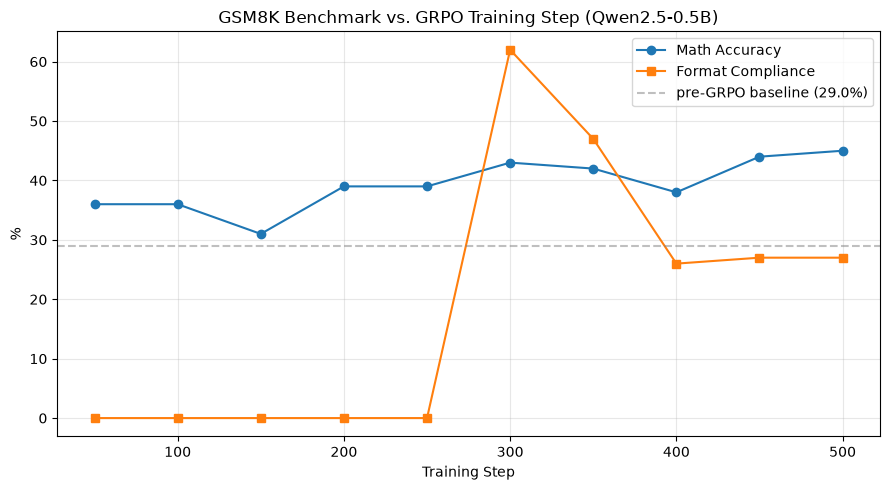

In [7]:
import os, glob, re
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import matplotlib.pyplot as plt

BASE_MODEL = "Qwen/Qwen2.5-0.5B-Instruct"
CHECKPOINT_DIR = "qwen2.5-0.5b-grpo-output"

def evaluate_checkpoint(adapter_path, eval_examples, base_model=None, tokenizer=None):
    """Runs your GSM8K benchmark on one checkpoint. Reuses base_model if passed to avoid reloading."""
    if base_model is None:
        base_model = AutoModelForCausalLM.from_pretrained(
            BASE_MODEL, dtype=compute_dtype, device_map="auto"
        )
    if tokenizer is None:
        tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

    model = PeftModel.from_pretrained(base_model, adapter_path)
    model.eval()

    correct, formatted = 0, 0
    pattern = r"^<reasoning>[\s\S]*?<\/reasoning>\s*<answer>[\s\S]*?<\/answer>$"

    for ex in eval_examples:
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": ex["prompt"]},
        ]
        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False, add_generation_prompt=True,
        )
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=384, do_sample=False)
        response = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

        extracted = extract_last_number(response)
        if extracted == ex["answer"]:
            correct += 1
        if re.match(pattern, response):
            formatted += 1

    model = model.unload()  # detach adapter, keep base_model reusable
    n = len(eval_examples)
    return correct / n * 100, formatted / n * 100

# Load held-out 100-problem eval set
eval_examples = [
    {
        "prompt": ex["question"],
        "answer": extract_hash_answer(ex["answer"]),
    }
    for ex in eval_dataset_100
]

checkpoints = sorted(
    glob.glob(f"{CHECKPOINT_DIR}/checkpoint-*"),
    key=lambda p: int(re.search(r"checkpoint-(\d+)", p).group(1))
)

base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL, dtype=compute_dtype, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

steps, accs, fmts = [], [], []
for ckpt in checkpoints:
    step = int(re.search(r"checkpoint-(\d+)", ckpt).group(1))
    acc, fmt = evaluate_checkpoint(ckpt, eval_examples, base_model, tokenizer)
    steps.append(step); accs.append(acc); fmts.append(fmt)
    print(f"Step {step}: accuracy={acc:.1f}%, format={fmt:.1f}%")

plt.figure(figsize=(9, 5))
plt.plot(steps, accs, marker="o", label="Math Accuracy")
plt.plot(steps, fmts, marker="s", label="Format Compliance")
pre_baseline = pre_acc if "pre_acc" in globals() else 31.0
plt.axhline(y=pre_baseline, color="gray", linestyle="--", alpha=0.5, label=f"pre-GRPO baseline ({pre_baseline:.1f}%)")
plt.xlabel("Training Step")
plt.ylabel("%")
plt.title("GSM8K Benchmark vs. GRPO Training Step (Qwen2.5-0.5B)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("checkpoint_curve.png", dpi=150)
plt.show()

## 5. Inference Verification
We query our trained model to verify that it generates reasoning and mathematical solutions structured under correct tags.

In [8]:
merged_model.eval()
merged_model.generation_config.max_length = None

post_grpo_responses_100 = []
post_grpo_correct = 0
post_grpo_format = 0

print("=== Running Post-GRPO Benchmark on 100 GSM8K Test Problems ===")

for i, example in enumerate(eval_dataset_100):
    question = example["question"]
    ground_truth = extract_hash_answer(example["answer"])

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]

    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    )

    input_ids = inputs if isinstance(inputs, torch.Tensor) else inputs["input_ids"]
    input_ids = input_ids.to("cuda")

    with torch.no_grad():
        outputs = merged_model.generate(
            input_ids=input_ids, max_new_tokens=384, pad_token_id=tokenizer.eos_token_id
        )

    post_resp = tokenizer.decode(
        outputs[0][input_ids.shape[1] :], skip_special_tokens=True
    ).strip()

    post_grpo_responses_100.append(post_resp)
    ext_ans = extract_last_number(post_resp)

    if ext_ans == ground_truth:
        post_grpo_correct += 1

    if re.match(pattern, post_resp):
        post_grpo_format += 1

    if (i + 1) % 20 == 0:
        print(
            f"Evaluated {i + 1}/100 problems | Current Accuracy: {post_grpo_correct / (i + 1) * 100:.1f}%"
        )

post_acc = (post_grpo_correct / 100) * 100
post_fmt = (post_grpo_format / 100) * 100
acc_delta = post_acc - pre_acc
fmt_delta = post_fmt - pre_fmt

print("\n" + "=" * 60)
print(">>> FINAL GSM8K 100-PROBLEM BENCHMARK RESULTS <<<")
print(f"Pre-GRPO Format Compliance:  {pre_fmt:.1f}%")
print(f"Post-GRPO Format Compliance: {post_fmt:.1f}%")
print(f"Format Compliance Delta:    {'+' if fmt_delta >= 0 else ''}{fmt_delta:.1f}%\n")
print(f"Pre-GRPO Math Accuracy:      {pre_acc:.1f}%")
print(f"Post-GRPO Math Accuracy:     {post_acc:.1f}%")
print(f"Math Accuracy Delta:        {'+' if acc_delta >= 0 else ''}{acc_delta:.1f}%")
print("=" * 60 + "\n")
print("=== Detailed 5-Example Side-by-Side Comparison ===")

for i in range(5):
    example = eval_dataset_100[i]
    question = example["question"]
    ground_truth = extract_hash_answer(example["answer"])
    print(f"=== Test Example {i + 1} ===")
    print(f"Question: {question}")
    print(f"Ground Truth Answer: {ground_truth}")
    print(
        f"\033[91mBefore GRPO (Pre-trained 0.5B Model):\033[0m\n{pre_grpo_responses_100[i]}\n"
    )
    print(
        f"\033[92mAfter GRPO (RL Aligned 0.5B Model):\033[0m\n{post_grpo_responses_100[i]}\n"
    )
    print("-" * 80 + "\n")

=== Running Post-GRPO Benchmark on 100 GSM8K Test Problems ===


Evaluated 20/100 problems | Current Accuracy: 20.0%


Evaluated 40/100 problems | Current Accuracy: 22.5%


Evaluated 60/100 problems | Current Accuracy: 23.3%


Evaluated 80/100 problems | Current Accuracy: 20.0%


Evaluated 100/100 problems | Current Accuracy: 25.0%

>>> FINAL GSM8K 100-PROBLEM BENCHMARK RESULTS <<<
Pre-GRPO Format Compliance:  0.0%
Post-GRPO Format Compliance: 0.0%
Format Compliance Delta:    +0.0%

Pre-GRPO Math Accuracy:      29.0%
Post-GRPO Math Accuracy:     25.0%
Math Accuracy Delta:        -4.0%

=== Detailed 5-Example Side-by-Side Comparison ===
=== Test Example 1 ===
Question: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
Ground Truth Answer: 18
Before GRPO (Pre-trained 0.5B Model):
To calculate how much Janet makes from selling the remaining eggs at the farmers' market each day, we need to follow these steps:

1. **Calculate total number of eggs laid by ducks per day:**
   - Breakfast consumption: \(3\) eggs/day
   - Muffin baking: \(4\) 